**Upload Dataset**

In [ ]:
# import modules
!pip install -q selfies
from google.colab import drive
import numpy as np
import csv
import pandas as pd
import selfies as sf
from matplotlib.ticker import PercentFormatter

In [ ]:
# mount the drive
drive.mount('/content/drive')
dir = "/content/drive/My Drive/Colab_Notebooks/IL_Manuscript/Model_2/"

# import the SELFIES alphabet
SELFIES_alphabet = np.load(dir + 'data/SELFIES_alphabet.npy',allow_pickle='TRUE').item()

# import the SELFIES dataset
with open(dir + 'data/density_dataset.csv', newline='') as file:
    dataset = pd.read_csv(file)

Mounted at /content/drive


**Molecular Descriptor**

*One-Hot Encoding of Molecular Physical Structure*

In [ ]:
# one-hot encoding
def OneHot(selfies):
    label, one_hot = sf.selfies_to_encoding(
            selfies=selfies,
            vocab_stoi=SELFIES_alphabet,
            pad_to_len=76,
            enc_type = "both")
    return one_hot

for i in range (0,len(dataset.index)):
  dataset['ion1'][i] = OneHot(dataset.iloc[i][1]) + OneHot(dataset.iloc[i][2])

del dataset['ion2']
dataset.rename(columns = {'ion1':'ions'}, inplace = True)

<ipython-input-5-f9e429160452>:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dataset['ion1'][i] = OneHot(dataset.iloc[i][1]) + OneHot(dataset.iloc[i][2])


*Normalize Temperature*

In [ ]:
# normalize temperature
def min_max_scaler(col):
  return (col - col.min()) / (col.max() - col.min())
dataset['temperature'] = min_max_scaler(dataset['temperature'])

# append temperature to one-hot encoded molecular structure
for i in range (0,len(dataset.index)):
  dataset['ions'][i] = np.concatenate((np.array(dataset['ions'][i]).reshape(7904,), np.array([dataset['temperature'][i]])))

<ipython-input-6-643e3a4385e8>:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dataset['ions'][i] = np.concatenate((np.array(dataset['ions'][i]).reshape(7904,), np.array([dataset['temperature'][i]])))


*Proprocess Density*

In [ ]:
dataset['density'] = dataset['density']/1000

**Density DNN Model**

*Setup*

In [ ]:
# upload transfer_learning.py
from google.colab import files
files.upload()

Saving transfer_learning.py to transfer_learning.py


{'transfer_learning.py': b'from __future__ import print_function, division\n\nimport torch\nimport torch.nn as nn \nimport torch.optim as optim\nfrom torch.optim import lr_scheduler\nfrom torch.autograd import Variable \n\nimport numpy as np \nimport matplotlib.pyplot as plt \nimport time \nimport os \n\nclass NeuralNet(nn.Module):\n\tdef __init__(self, input_size, hidden_size_1, hidden_size_2, output_size):\n\t\tsuper(NeuralNet, self).__init__()\n\t\tself.fc1 = nn.Linear(input_size, hidden_size_1)\n\t\tself.fc2 = nn.Linear(hidden_size_1, hidden_size_2)\n\t\tself.fc3 = nn.Linear(hidden_size_2, output_size)\n\t\tself.relu = nn.ReLU()\n\n\tdef forward(self, x):\n\t\tout = self.fc1(x)\n\t\tout = self.relu(out)\n\t\tout = self.fc2(out)\n\t\tout = self.relu(out)\n\t\tout = self.fc3(out)\n\t\treturn out \n'}

In [ ]:
# transfer_learning.py
from transfer_learning import NeuralNet

# principal component analysis
from sklearn.decomposition import PCA

# DNN training
import torch
import torch.nn as nn
import torch.optim as optim
import os, sys
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_percentage_error, mean_squared_error
from tqdm import tqdm
import matplotlib.pyplot as plt
%matplotlib inline
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# permutation feature importance
!pip install -q eli5
from sklearn.neural_network import MLPRegressor
import eli5
from eli5.sklearn import PermutationImportance

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 216.2/216.2 kB 8.6 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done


In [ ]:
# input X and output y
X = []
y = []
for i in range(0,len(dataset.index)):
    X.append(dataset['ions'][i])
    y.append(dataset['density'][i])
for i in range(0,len(X)):
  X[i] = np.array(X[i]).reshape(7905,).astype(np.float32)
  y[i] = y[i].astype(np.float32)
X = np.array(X)
y = np.array(y)

In [ ]:
# principal component analysis
PC = []
for i in range (1, 51):
  PC.append('PC'+str(i))
pca = PCA(n_components = 50)
pca.fit(X)
data_pca = pca.transform(X)
df_PCA = pd.DataFrame(data_pca,columns=PC)
X_PCA = df_PCA.to_numpy()

*DNN Model*

100%|██████████| 50000/50000 [01:43<00:00, 482.56it/s]


The MAPE on test set is 0.8833298459649086%


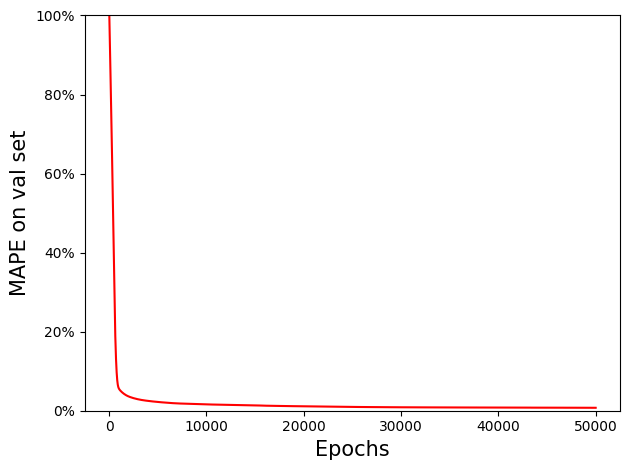

In [ ]:
# DNN training
input_size = 50
hidden_size_1 = 30
hidden_size_2 = 15
output_size = 1
learning_rate = 0.0001

model = NeuralNet(input_size, hidden_size_1, hidden_size_2, output_size).to(device)
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=learning_rate)

X_train, X_test, y_train, y_test = train_test_split(X_PCA, y, test_size=0.1, random_state=1)
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.2, random_state=1)

scores_epochs = list()
num_epochs = 50000
train_losses = []

for epoch in tqdm(range(num_epochs)):
    inputs = torch.from_numpy(X_train).to(device)
    labels = torch.from_numpy(y_train).to(device)

    outputs = model(inputs).view(-1,)
    loss = criterion(outputs, labels)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if epoch % 5 == 0:
        inputs_val = torch.from_numpy(X_val).to(device)
        labels_val = torch.from_numpy(y_val).to(device)

        outputs_val = model(inputs_val).view(-1,)
        score = mean_absolute_percentage_error(labels_val.data.cpu().numpy(), outputs_val.data.cpu().numpy())
        scores_epochs.append(score)

plt.gca().yaxis.set_major_formatter(PercentFormatter (1, decimals=0))
plt.plot(np.arange(0, num_epochs, 5), scores_epochs, color='red')
plt.ylim(0,1)
plt.xlabel('Epochs', size=15)
plt.ylabel('MAPE on val set', size=15)

X_test_tensor = torch.from_numpy(X_test).to(device)
y_test_tensor = torch.from_numpy(y_test).to(device)

output_test = model(X_test_tensor).view(-1,).cpu().data.numpy()

mape_test = mean_absolute_percentage_error(y_test_tensor.cpu().data.numpy(), output_test) * 100

print('The MAPE on test set is {}%'.format(mape_test))

plt.tight_layout()
plt.savefig(dir + 'figures/density/training_curve.png', dpi=600)
torch.save(model.state_dict(), dir + 'model/density/density_model.ckpt')

*Learning Curve*

In [ ]:
# learning curve
input_size = 50
hidden_size_1 = 30
hidden_size_2 = 15
output_size = 1
learning_rate = 0.0001

model = NeuralNet(input_size, hidden_size_1, hidden_size_2, output_size).to(device)
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=learning_rate)

x = 337
error_train = np.zeros(int(len(X_train)/x))
error_val = np.zeros(int(len(X_train)/x))

for i,N in enumerate(range(x, len(X_train)+1, x)):
  X_train_LC = X_train[:N]
  y_train_LC = y_train[:N]
  X_val_LC = X_val
  y_val_LC = y_val
  
  model = NeuralNet(input_size, hidden_size_1, hidden_size_2, output_size).to(device)
  criterion = nn.MSELoss()
  optimizer = optim.Adam(model.parameters(), lr=learning_rate)

  val_scores_epochs = list()
  train_scores_epochs = list()
  num_epochs = 50000

  for epoch in tqdm(range(num_epochs)):
      inputs = torch.from_numpy(X_train_LC).to(device)
      labels = torch.from_numpy(y_train_LC).to(device)

      outputs = model(inputs).view(-1,)
      loss = criterion(outputs, labels)

      optimizer.zero_grad()
      loss.backward()
      optimizer.step()

      train_scores_epochs.append(loss)

      inputs_val = torch.from_numpy(X_val_LC).to(device)
      labels_val = torch.from_numpy(y_val_LC).to(device)

      outputs_val = model(inputs_val).view(-1,)
      score = mean_squared_error(labels_val.data.cpu().numpy(), outputs_val.data.cpu().numpy())
      val_scores_epochs.append(score)

  error_train[i] = train_scores_epochs[-1]
  error_val[i] = val_scores_epochs[-1] 

df_error_train = pd.DataFrame(error_train)
df_error_val = pd.DataFrame(error_val)

df_error_train.to_csv(dir + 'figures/data/learning_curve/density_train.csv') 
df_error_val.to_csv(dir + 'figures/data/learning_curve/density_val.csv') 

100%|██████████| 50000/50000 [02:24<00:00, 345.72it/s]


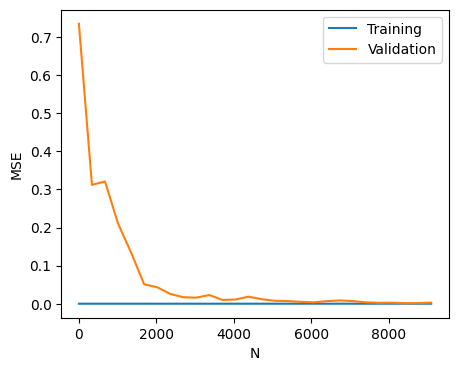

In [ ]:
x_axis = list()
for i,N in enumerate(range(x, len(X_train)+1, x)):
  x_axis.append(i*x)

with open(dir + 'figures/data/learning_curve/density_train.csv', newline='') as file1:
    csv_error_train = pd.read_csv(file1)
with open(dir + 'figures/data/learning_curve/density_val.csv', newline='') as file2:
    csv_error_val = pd.read_csv(file2)

csv_error_train.columns =['index', 'loss']
csv_error_val.columns =['index', 'loss']

lst_error_train = csv_error_train['loss'].tolist()
lst_error_val = csv_error_val['loss'].tolist()
plt.figure(figsize=(5,4))
plt.plot(x_axis, lst_error_train, label='Training')
plt.plot(x_axis, lst_error_val, label='Validation')
plt.legend()
plt.ylabel('MSE')
plt.xlabel('N')
plt.savefig(dir + 'figures/density/learning_curve.png', format='png', dpi=600)

*Permutation Feature Importance*

In [ ]:
regr = MLPRegressor(hidden_layer_sizes=(30, 15), solver='adam', activation = 'relu', random_state=1, max_iter=50000, learning_rate='constant',learning_rate_init=0.0001).fit(X_train, y_train)
perm = PermutationImportance(regr.fit(X_train,y_train), random_state=1).fit(X_test,y_test)
eli5.formatters.as_dataframe.explain_weights_df(perm, feature_names = df_PCA.columns.tolist(), top=50).to_csv(dir + 'figures/data/feature_importance/density.csv')